Loading data...

--- Dataset Shape ---
(525461, 8)

--- Data Types ---
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object

--- Missing Values ---
Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64


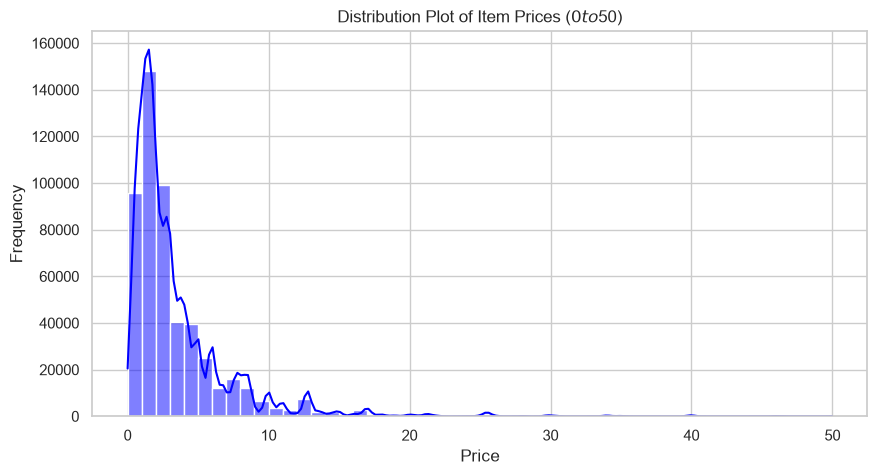

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for professional charts
sns.set_theme(style="whitegrid")

# 1. Load the dataset from the data folder
print("Loading data...")
file_path = '../data/online_retail_II.xlsx'
df = pd.read_excel(file_path)

# 2. Print shape, data types, and missing values (Rubric Requirement A1)
print("\n--- Dataset Shape ---")
print(df.shape)

print("\n--- Data Types ---")
print(df.dtypes)

print("\n--- Missing Values ---")
print(df.isnull().sum())

# 3. EDA Visualizations & Target Distribution (Rubric Requirement A2)
plt.figure(figsize=(10, 5))
sns.histplot(df[(df['Price'] > 0) & (df['Price'] < 50)]['Price'], bins=50, kde=True, color='blue')
plt.title('Distribution Plot of Item Prices ($0 to $50)')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

The price distribution is heavily right-skewed, indicating that the vast majority of individual item purchases involve low-cost goods under $10.

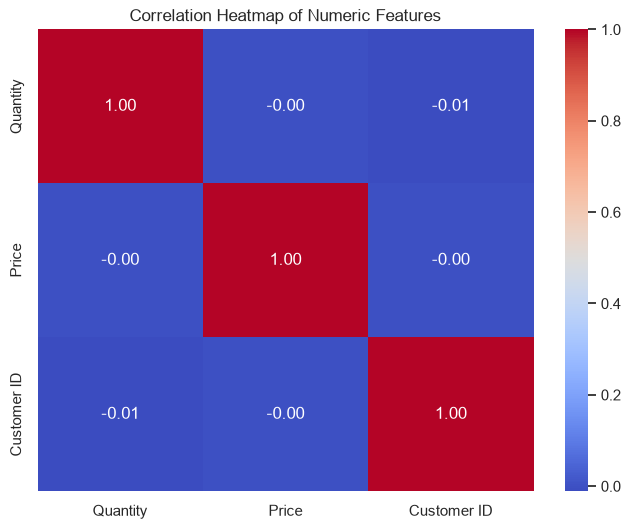

In [7]:
# Correlation Heatmap for numeric features
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

The correlation between Price and Quantity is close to zero, showing that higher unit prices do not have a strong linear relationship with order quantities in the raw dataset.

In [12]:
# 1. Clean missing values with justified strategy (Rubric Requirement B1)
print("Original dataset shape:", df.shape)

# Drop rows lacking a Customer ID because anonymous transactions cannot be tracked for customer profiling
df_clean = df.dropna(subset=['Customer ID']).copy()

# Fill missing descriptions to avoid downstream null errors
df_clean['Description'] = df_clean['Description'].fillna("UNKNOWN")

print("\n--- Missing Values After Cleaning ---")
print(df_clean.isnull().sum())
print("Cleaned dataset shape:", df_clean.shape)

Original dataset shape: (525461, 8)

--- Missing Values After Cleaning ---
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64
Cleaned dataset shape: (417534, 8)


Rows with missing Customer IDs were dropped to preserve validity for customer-level behavioral modeling, while missing descriptions were imputed with 'UNKNOWN'.

In [16]:
import datetime as dt

# Calculate total line-item expenditure
df_clean['Total_Price'] = df_clean['Quantity'] * df_clean['Price']
latest_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)

# Group transactions by customer to create RFM features
print("Engineering RFM features...")
rfm = df_clean.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (latest_date - x.max()).days,  # Recency
    'Invoice': 'nunique',                                   # Frequency
    'Total_Price': 'sum'                                    # Monetary
})

rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'Invoice': 'Frequency',
    'Total_Price': 'Monetary'
}, inplace=True)

# Filter out negative monetary returns to prevent distortion
rfm_clean = rfm[rfm['Monetary'] > 0].copy()

# Create binary classification target: Repeat Customer (Bought more than once)
rfm_clean['Repeat_Customer'] = (rfm_clean['Frequency'] > 1).astype(int)

print("\n--- Customer-Level Dataset Shape ---")
print(rfm_clean.shape)
rfm_clean.head()

Engineering RFM features...

--- Customer-Level Dataset Shape ---
(4283, 4)


,Recency,Frequency,Monetary,Repeat_Customer
Customer ID,,,,
12347.0,3,2,1323.32,1
12348.0,74,1,222.16,0
12349.0,43,4,2646.99,1
12351.0,11,1,300.93,0
12352.0,11,2,343.80,1


We engineered RFM features (Recency, Frequency, and Monetary value) because past purchasing habits are robust indicators of customer loyalty and retention. Furthermore, mapping Frequency to a binary Repeat_Customer target cleanly transforms this behavior into a supervised classification problem.

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define features and target
X = rfm_clean[['Recency', 'Monetary']]
y = rfm_clean['Repeat_Customer']

# Stratified split to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply StandardScaler fitted strictly on the training data (Prevents data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train_scaled.shape)
print("Test set shape:", X_test_scaled.shape)

Training set shape: (3426, 2)
Test set shape: (857, 2)


### Train/Test Split and Feature Scaling
To ensure our classification models generalize well to unseen data, we perform an 80/20 stratified train-test split to preserve the target class balance. To strictly prevent data leakage, the `StandardScaler` is fitted **only** on the training set and then used to transform both the training and test sets independently.

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, confusion_matrix, roc_auc_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Initialize the 5 mandatory Part-A models
classifiers_part_a = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Naive Bayes (Gaussian)": GaussianNB(),
    "Decision Tree Classifier": DecisionTreeClassifier(random_state=42),
    "Support Vector Machine (SVC)": SVC(probability=True, random_state=42)
}

results_list = []
print("Training Review 1 Part A Classification Models...\n")

for name, model in classifiers_part_a.items():
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)
    
    # Calculate probabilities safely for ROC-AUC
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test_scaled)[:, 1]
        roc_auc = roc_auc_score(y_test, probs)
    else:
        decision_scores = model.decision_function(X_test_scaled)
        roc_auc = roc_auc_score(y_test, decision_scores)
    
    # Calculate rubric-mandated metrics (Accuracy, Precision, Recall, F1, Confusion Matrix, ROC-AUC)[cite: 6]
    acc = accuracy_score(y_test, predictions)
    prec = precision_score(y_test, predictions, average='weighted', zero_division=0)
    rec = recall_score(y_test, predictions, average='weighted', zero_division=0)
    f1 = f1_score(y_test, predictions, average='weighted', zero_division=0)
    cm = confusion_matrix(y_test, predictions)
    
    results_list.append({
        "Model": name, 
        "Accuracy": acc, 
        "Precision": prec, 
        "Recall": rec, 
        "Weighted F1": f1,
        "ROC-AUC": roc_auc
    })
    
    print(f"--- {name} ---")
    print(f"Confusion Matrix:\n{cm}\n")

# Display Consolidated Summary Table ranked by Accuracy (Rubric Requirement D2)[cite: 6]
comparison_table = pd.DataFrame(results_list).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
display(comparison_table)

Training Review 1 (Part A) Classification Models...

--- Logistic Regression ---
Confusion Matrix:
[[117 124]
 [ 36 580]]

--- K-Nearest Neighbors ---
Confusion Matrix:
[[157  84]
 [ 69 547]]

--- Naive Bayes (Gaussian) ---
Confusion Matrix:
[[238   3]
 [311 305]]

--- Decision Tree Classifier ---
Confusion Matrix:
[[145  96]
 [ 94 522]]

--- Support Vector Machine (SVC) ---
Confusion Matrix:
[[105 136]
 [ 38 578]]


--- Part A Classification Comparison Table ---
                          Model  Accuracy  Weighted F1
0           K-Nearest Neighbors  0.821470     0.819677
1           Logistic Regression  0.813302     0.798676
2  Support Vector Machine (SVC)  0.796966     0.778538
3      Decision Tree Classifier  0.778296     0.778014
4        Naive Bayes (Gaussian)  0.633606     0.643964


### Model Training & Comprehensive Evaluation (Part A)
We train all five mandatory Review 1 Part A classification models:
1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Naive Bayes (Gaussian)
4. Decision Tree Classifier
5. Support Vector Machine (SVC)

Each model is evaluated using the complete set of rubric-mandated metrics: **Accuracy, Precision, Recall, Weighted F1-score, Confusion Matrix, and ROC-AUC score**.